# Case Study: Population modeling with radial velocity data

One of the main motivations for developing [The Joker](https://thejoker.readthedocs.io) and the methods implemented in `harv` is to enable population-level inference of binary-star properties from large spectroscopic surveys with heterogenous time sampling. In this tutorial, we demonstrate how to use `harv` to perform a _hierarchical inference_ of population properties (e.g., the eccentricity distribution, the overall binary fraction) for a population of simulated binary-star systems. We will:

0. Load radial velocity data for 100 simulated systems (a mix of binary-star and single-star systems), with binary orbital properties drawn from an input eccentricity distribution with a known binary fraction.
1. Generate a prior sample cache on disk using `make_prior_cache(...)` so the prior samples are generated once and reused across all stars.
2. Run the rejection sampler on every source using `RejectionSampler.run_with_samples(..., prior_cache_path)`. Because each star has the same number of epochs, the JIT cache is hit after the first call and per-star runtime drops for subsequent calls. 
3. Infer the parameters of the eccentricity distribution using the importance-sampling trick of [Hogg et al. (2010)](https://arxiv.org/abs/1008.4146).
4. Infer the "close binary fraction" using a similar but more complex importance-sampling approach.

> **Note:** We assume every star has the same number of observation epochs. This lets JAX reuse the JIT cache across all 100 rejection-sampler calls. For real surveys with heterogeneous epoch counts, you may want to pad the observation arrays to a common length.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
import numpyro

numpyro.set_host_device_count(4)

In [3]:
import copy
import pathlib
import time
from types import SimpleNamespace

import corner
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import quaxed.numpy as jnp
import scipy.optimize as opt
from numpyro.infer import MCMC, NUTS
from population_binary_fraction_helpers import load_population
from unxt import Q, ustrip

import harv
from harv.kepler import masses
from harv.samplers.samples import pad_and_stack_samples

%matplotlib inline

## Load the (simulated) data

We load simulated stellar radial velocity data for 100 sources. The simulator is run separately and the data are cached as a single HDF5 file with arrays of shape `(N_stars, N_epochs)` for `time`, `rv`, and `rv_err`, plus a small table of truth values for the simulated input parameters. 

In [4]:
DATA_PATH = pathlib.Path()


datasets, truths = load_population("../data/synthetic_binary_population/population.h5")
N_stars = len(datasets)
N_epochs = int(datasets[0].time.shape[0])
print(f"Loaded {N_stars} sources with {N_epochs} epochs per source.")

Loaded 100 sources with 10 epochs per source.


### Quick look at the data

Sanity check: a few example RV curves:

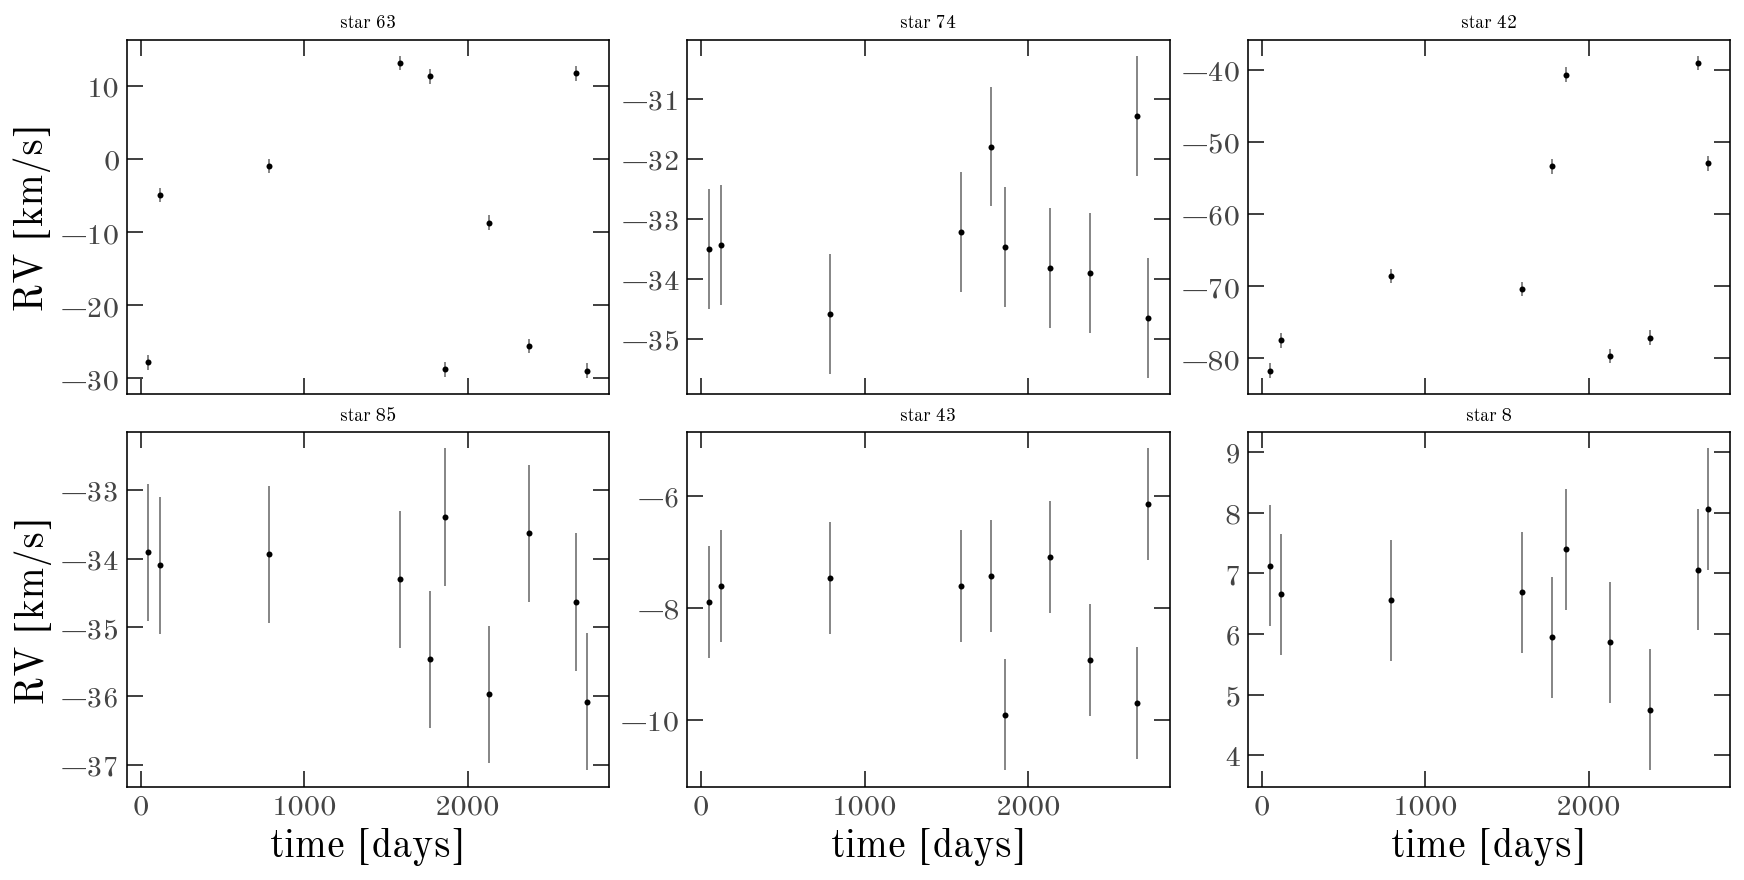

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, layout="constrained")

rng = np.random.default_rng(42)
for ax, idx in zip(axes.flat, rng.choice(N_stars, size=6, replace=False), strict=True):
    d = datasets[int(idx)]
    d.plot(ax=ax, add_labels=False)
    ax.set_title(f"star {int(idx)}", fontsize=9)

for ax in axes[1]:
    ax.set_xlabel("time [days]")
for ax in axes[:, 0]:
    ax.set_ylabel("RV [km/s]")

## Build the prior cache

The prior cache is a single HDF5 file containing prior samples in orbital parameters and any other explicitly-sampled (or nonlinear) parameters used in the model you are using to represent the data. Here, we will use a standard orbital model that assumes that the RV measurements correspond to the spectral lines from one of the stars in a binary-star system. 

We'll also use the standard parameterization of the orbital model from {class}`harv.models.StandardRV`, which uses a log-uniform prior in period and uniform priors on the angular parameters. We'll adopt a truncated normal distribution for eccentricity. You can read more about the default prior in {meth}`harv.models.StandardRV.default_prior`.

In [6]:
prior = harv.models.StandardRV().default_prior(
    period_min=Q(0.5, "day"),
    period_max=Q(1e4, "day"),
    sigma_K0=Q(30.0, "km/s"),
    sigma_v0=Q(50.0, "km/s"),
    eccentricity=dist.TruncatedNormal(0.1, 0.25, low=0.0, high=1.0),
)
model = harv.models.RVModel()

In [7]:
prior_cache_path = pathlib.Path("population-cache/population-prior-cache.h5")
prior_cache_path.parent.mkdir(parents=True, exist_ok=True)

t0 = time.time()
harv.make_prior_cache(
    prior,
    model,
    n_samples=10_000_000,  # generate
    filename=prior_cache_path,
    key=jr.key(0),
    batch_size=1_000_000,  # You can adjust this
    return_logprobs=True,
)
print(f"Built prior cache in {time.time() - t0:.1f}s at {prior_cache_path!s}")

Built prior cache in 1.7s at population-cache/population-prior-cache.h5


Now we inspect the prior cache. A prior-sample file is just a serialized {class}`harv.samplers.Samples` file but with empty linear parameters, so {meth}`harv.samplers.Samples.from_hdf5` loads it directly to inspect the prior samples:

In [8]:
prior_cache_samples = harv.Samples.from_hdf5(prior_cache_path)
print(f"n_samples = {prior_cache_samples.n_samples}")
print(f"nonlinear keys: {sorted(prior_cache_samples.nonlinear)}")

n_samples = 10000000
nonlinear keys: ['arg_peri', 'eccentricity', 'period', 'phase_peri']


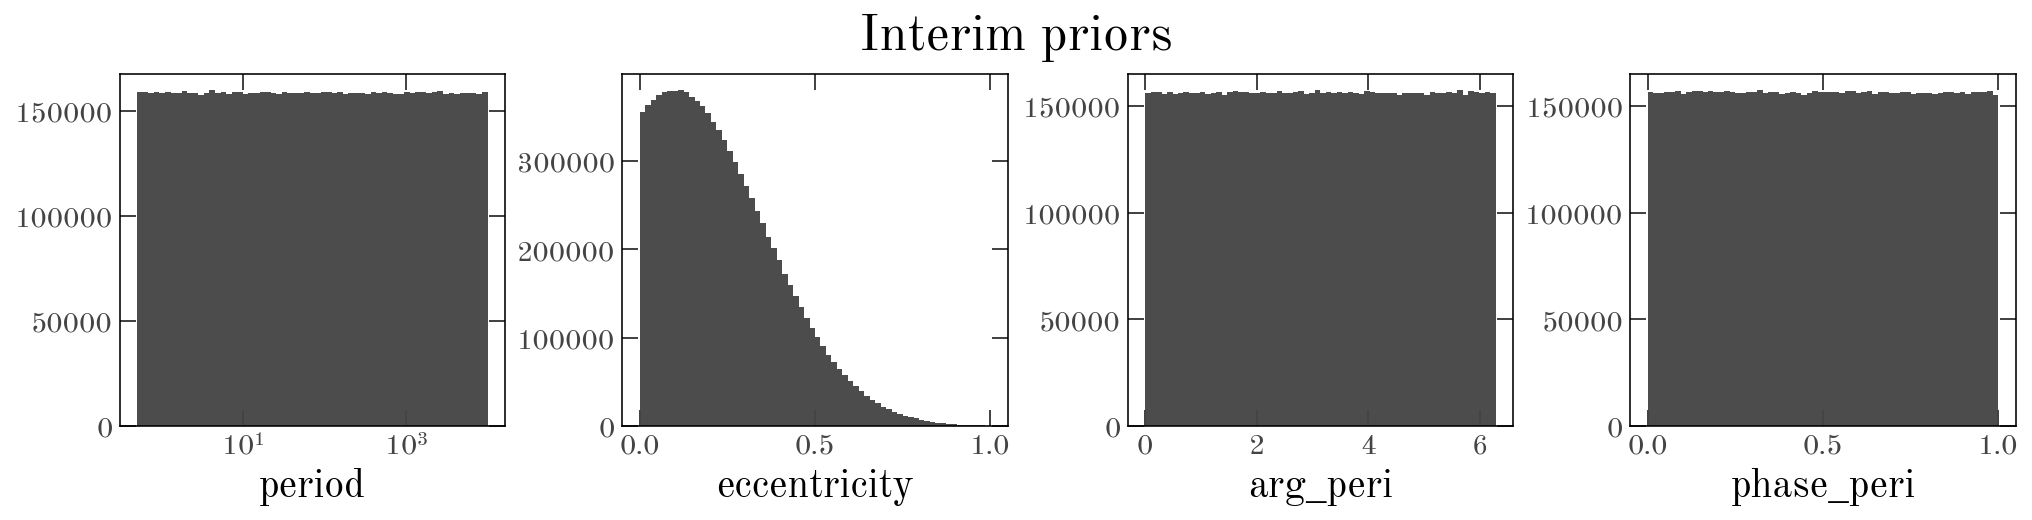

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), layout="constrained")
for ax, name in zip(
    axes, ["period", "eccentricity", "arg_peri", "phase_peri"], strict=True
):
    vals = prior_cache_samples[name].value
    bins = np.geomspace(vals.min(), vals.max(), 64) if name == "period" else 64
    ax.hist(vals, bins=bins, alpha=0.7)
    ax.set_xlabel(name)
    if name == "period":
        ax.set_xscale("log")
    fig.suptitle("Interim priors", fontsize=26)

## Run rejection sampling on all 100 sources

Now we run the rejection sampler on all of the sources in our dataset. We use the {meth}`harv.samplers.RejectionSampler.run_with_samples` method, which differs from the standard `run` method in that it takes either an in-memory `Samples` object as input, or the path to a prior cache file instead of generating new samples on the fly. This allows us to reuse the same prior samples across all 100 sources, which is much faster than generating new samples for each source.

Each call to `sampler.run_with_samples(data, PRIOR_CACHE_FILENAME)` streams the prior cache from disk in `batch_size`-row chunks. The expensive computation is evaluating the model (marginal) log-likelihoods for all of the prior samples with the data for a given star. Because the model is JIT-compiled, the first call to `run_with_samples` will be slow as the JIT cache is built, but subsequent calls will be faster because the JIT cache is hit. 

We'll store the posterior samples for each star in a separate HDF5 file in the `population-cache/population-posteriors` directory:

In [10]:
posteriors_path = pathlib.Path("population-cache/posteriors")
posteriors_path.mkdir(parents=True, exist_ok=True)

We also need to specify how many posterior samples to retain per star. If your population model is simple, you probably don't need more than a few hundred posterior samples per star to get a good estimate of the population parameters. If your population model is more complex, you may need more posterior samples per star to get a good estimate of the population parameters. Here we adopt 1024, but you should increase this substantially if your population model has more parameters or is more complex.

In [11]:
max_post_samples = 1024

In [12]:
sampler = harv.RejectionSampler(prior, model, batch_size=1_000_000)

posteriors: list[harv.Samples] = []
timings: list[float] = []

for n, data in enumerate(datasets):
    t0 = time.time()

    # Note that we set a per-star random number seed: this is important for ensuring
    # reproducible randomness across the stars
    samples = sampler.run_with_samples(
        data,
        prior_cache_path,
        max_posterior_samples=max_post_samples,
        seed=n,
        return_logprobs=True,
        return_evidence_stats=True,
    )
    dt = time.time() - t0
    timings.append(dt)
    posteriors.append(samples)
    samples.to_hdf5(posteriors_path / f"star_{n:04d}.h5")

    if n < 4 or n % 25 == 0:
        print(f"star {n:>3}: {samples.n_samples:>4} accepted in {dt:.2f}s")

print()
print(f"first call  : {timings[0]:.2f}s (JIT compile included)")
print(f"second call : {timings[1]:.2f}s")
print(f"median      : {np.median(timings):.2f}s")
print(f"total       : {sum(timings):.1f}s for {N_stars} stars")

star   0:    1 accepted in 3.45s
star   1:    1 accepted in 2.30s
star   2:    2 accepted in 3.10s
star   3: 1024 accepted in 3.58s
star  25: 1024 accepted in 2.57s
star  50:   78 accepted in 3.75s
star  75: 1024 accepted in 2.66s

first call  : 3.45s (JIT compile included)
second call : 2.30s
median      : 2.62s
total       : 276.2s for 100 stars


### Per-source rejection sampling timing

Having the same `data` pytree shape across all 100 sources means the second-and-onward calls hit the JIT cache. The first-call cost is dominated by compilation; subsequent calls should be bounded by disk I/O + linear-parameter resampling:


/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_41684/1615482795.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


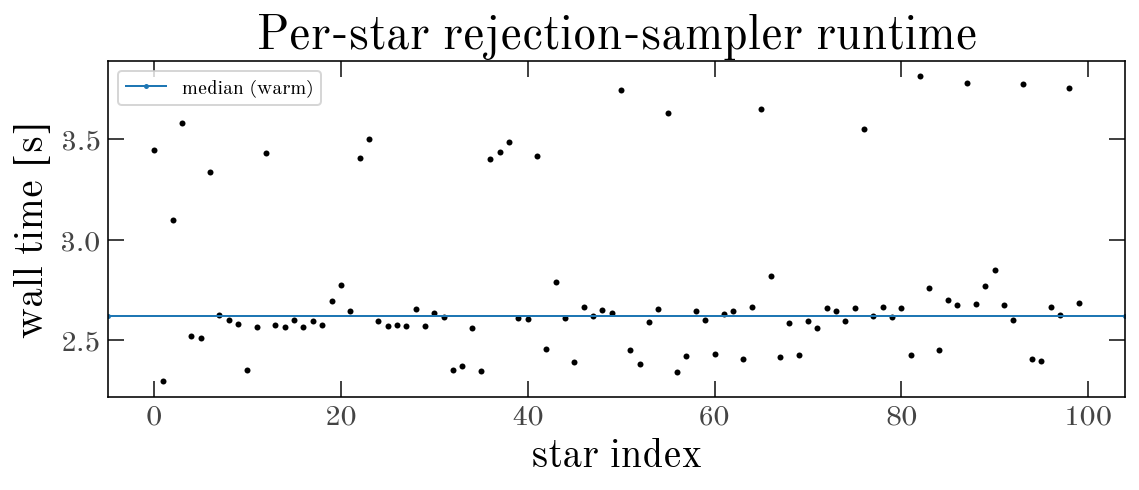

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(timings, "o", ms=3)
ax.axhline(np.median(timings[1:]), color="C1", lw=1, label="median (warm)")
ax.set_xlabel("star index")
ax.set_ylabel("wall time [s]")
ax.set_title("Per-star rejection-sampler runtime")
ax.legend()
fig.tight_layout()

### Histogram of accepted posterior samples

A handful of stars may end up with very few accepted samples, $K_n$ (number of posterior samples $K$ for star indexed by $n$). This usually happens when the data are very constraining and so the modes of the likelihood are very narrow (i.e. the orbital solution is well-determined). In principle, if your population model over parameters like period and eccentricity is broad, follow-up hierarchical analyses can use a variable number of returned samples and should not be too impacted by having different numbers of posterior samples per star. More on this in the next cells.

/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_41684/521870765.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


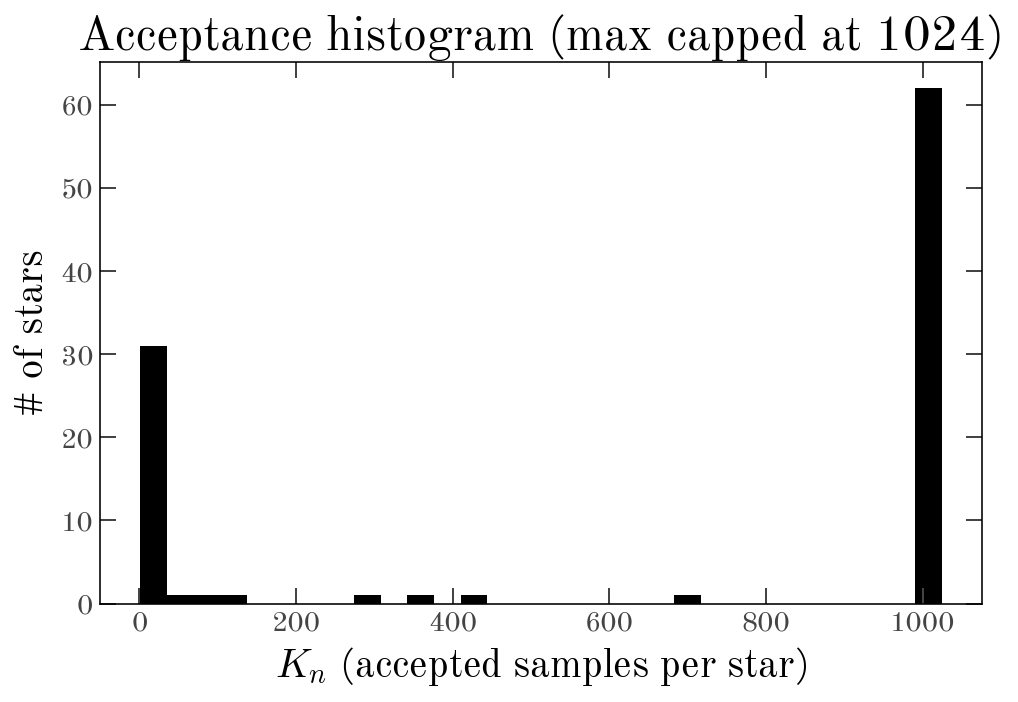

In [14]:
n_accept = np.array([s.n_samples for s in posteriors])
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(n_accept, bins=30)
ax.set_xlabel("$K_n$ (accepted samples per star)")
ax.set_ylabel("# of stars")
ax.set_title(f"Acceptance histogram (max capped at {max_post_samples})")
fig.tight_layout()

## Generate more posterior samples with MCMC

The hierarchical inference framework we introduce below uses the per-source posterior samples from the rejection sampler within the population likelihood. This involves Monte Carlo sums of the form $\frac{1}{K_n} \sum_j p(e_{nj} \mid \boldsymbol{\alpha}) / p_\mathrm{int}(e_{nj})$, so a star with very few accepted samples (small $K_n$) contributes a noisy term that can sometimes impact the gradient of the population likelihood. Two failure modes lead to small $K_n$ after rejection:

1. *A well-constrained but low-acceptance posterior*: the likelihood is sharply peaked, so almost every prior draw is rejected, but the surviving sample(s) are tightly clustered around the true orbit. 
2. *Certain multi-modal posteriors*: the rejection samples may be spread across a small number of well-separated modes. This can often happen when the data have a long time baseline, or are otherwise fairly strongly constraining of the orbit, but where some period aliasing or other degeneracies in the data prevent a unique orbital solution. 

For the first case, we can simply generate more posterior samples with MCMC, warm-started from the rejection samples. For the second case, the multi-modality can lead to poor MCMC performance and a very noisy importance-sampling sum that can cause problems for gradient-based inference of the population parameters. In this case, we can flag the star as "multi-modal" and keep it as-is in the importance-sampling sum, but with a small $K_n$ to downweight its contribution to the population likelihood.

We use `Samples.period_unimodal(data)` to distinguish the two cases. Stars below the threshold and judged unimodal are re-sampled with {class}`harv.samples.NumpyroSampler` (warm-started from the rejection samples). The multimodal cases with few returned samples are flagged and kept as-is — the importance-sampling sum still uses them, just with a small $K_n$.


In [15]:
stars_thin = [n for n, s in enumerate(posteriors) if s.n_samples < max_post_samples]
print(f"{len(stars_thin)} stars have fewer than {max_post_samples} samples")

38 stars have fewer than 1024 samples


In [16]:
n_warmup = 512
n_samples = 512
n_chains = 2

mcmc_sampler = harv.NumpyroSampler(prior, model)

In [17]:
followed_up: list[int] = []
multimodal: list[int] = []
skipped_empty: list[int] = []
mcmc_failed: list[tuple[int, str]] = []

for n in stars_thin:
    samples = posteriors[n]
    data = datasets[n]

    if samples.n_samples == 0:
        skipped_empty.append(n)
        continue

    if not samples.period_unimodal(data):
        multimodal.append(n)
        continue

    t0 = time.time()
    new_samples = mcmc_sampler.run(
        data,
        init_samples=samples,
        seed=1 + n,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=n_chains,
        return_logprobs=True,
    )
    dt = time.time() - t0

    posteriors[n] = new_samples[:max_post_samples]
    for k in samples.metadata:
        if k not in posteriors[n].metadata:
            posteriors[n].metadata[k] = samples.metadata[k]
    new_samples.to_hdf5(posteriors_path / f"star_{n:04d}.h5")
    followed_up.append(n)

print()
print("summary:")
print(f"  followed-up (MCMC):           {len(followed_up)}")
print(f"  thin & multimodal (kept):     {len(multimodal)}")

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

...

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]

  0%|          | 0/1024 [00:00<?, ?it/s]


summary:
  followed-up (MCMC):           24
  thin & multimodal (kept):     14


Now, almost all of the stars have enough posterior samples to contribute a stable term to the population likelihood. A few stars are flagged as being multi-modal with few returned samples. For those cases, we could try using a different MCMC sampling technique (e.g., Nested sampling) to generate more samples. For now, we'll just keep them as-is and accept that they contribute a noisy term to the population likelihood.

/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_41684/2602271768.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


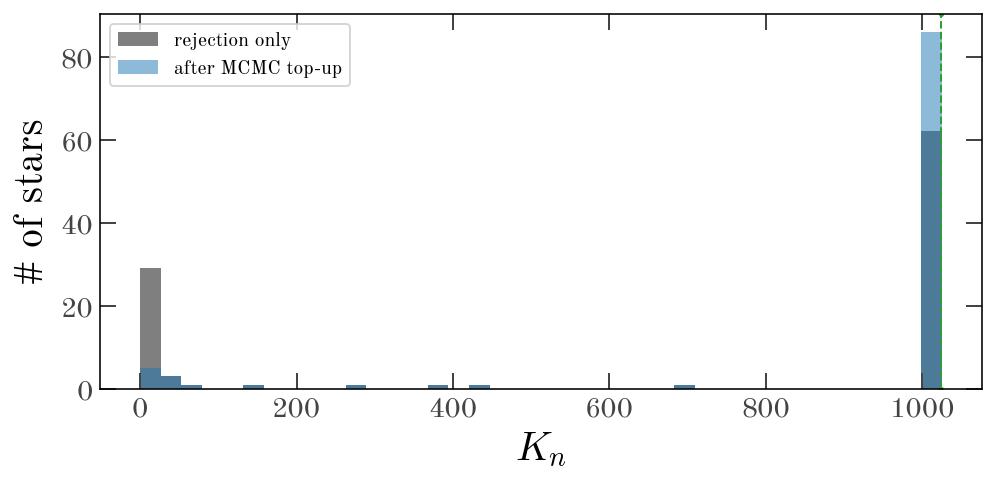

In [18]:
n_accept_after = np.array([s.n_samples for s in posteriors])
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(0, max(n_accept_after.max(), max_post_samples) + 1, 40)
ax.hist(n_accept, bins=bins, alpha=0.5, label="rejection only")
ax.hist(n_accept_after, bins=bins, alpha=0.5, label="after MCMC top-up")
ax.axvline(max_post_samples, color="C3", lw=1, ls="--")
ax.set_xlabel("$K_n$")
ax.set_ylabel("# of stars")
ax.legend()
fig.tight_layout()

## Inferring the eccentricity distribution with a hierarchical model

We now have posterior samples for each star in our population. 
We can use these samples to infer a _hierarchical model_ of the parameters of a population-level eccentricity distribution.
First, some mathematical context.

We want to infer the parameters $\boldsymbol{\alpha}$ of a population-level eccentricity distribution $p(e \mid \boldsymbol{\alpha})$. 
For example, $\boldsymbol{\alpha}$ could represent the mean and standard deviation of a truncated normal distribution on $e$, or the shape parameters of a Beta distribution on $e$. 
We have (a finite number of) posterior samples over the per-source parameters $\boldsymbol{\theta}$. The standard hierarchical likelihood is
$$
\mathcal{L}(\{D_n\} \mid \boldsymbol{\alpha}, \boldsymbol{\theta}) = 
    \prod_n p(D_n \mid \theta_n) \, p(\theta_n \mid \boldsymbol{\alpha})
    \quad .
$$
where $p(D_n \mid \theta_n)$ is the corresponds to the likelihood of the observed radial velocity data $D_n$ for star $n$ given the orbital parameters of that star, $\theta_n$.
The term $p(\theta_n \mid \boldsymbol{\alpha})$ is the connection between the orbital parameters for that star and the population parameters $\boldsymbol{\alpha}$.
We may then be interested in the hierarchical likelihood marginalized over the per-source orbital parameters, $p(D_n \mid \alpha)$, which is
$$
\hat{\mathcal{L}}(\{D_n\} \mid \boldsymbol{\alpha}, \boldsymbol{\theta}) = 
    \prod_n \int \mathrm{d}\theta_n \, 
        p(D_n \mid \theta_n) \, p(\theta_n \mid \boldsymbol{\alpha})
    \quad .
$$

Following [Hogg et al. 2010](https://arxiv.org/abs/1008.4146) or [Price-Whelan et al. 2020](https://arxiv.org/abs/2002.00014), if we have $K_n$ posterior samples for star $n$ over the orbital parameters with sample index $k$ given by $\theta_{nk}$ generated under an *interim* prior $p_\mathrm{int}(\theta)$, the marginalization integral can be computed with a Monte Carlo sum:
$$
\int \mathrm{d}\theta_n \, p(D_n \mid \theta_n)\, p(\theta \mid \boldsymbol{\alpha})
    \,\;\approx\; 
    \frac{Z_n}{K_n} \sum_{k=1}^{K_n} 
        \frac{p(\theta_{nk} \mid \boldsymbol{\alpha})}{p_\mathrm{int}(\theta_{nk})},
$$
where $Z_n$ is the evidence for star $n$ (independent of $\boldsymbol{\alpha}$). So up to a constant in $\boldsymbol{\alpha}$:
$$
\ln \mathcal{L}(\{D_n\} \mid \boldsymbol{\alpha}) \;=\; \sum_n \ln \!\left[\frac{1}{K_n} \sum_{k=1}^{K_n} \frac{p(\theta_{nk} \mid \boldsymbol{\alpha})}{p_\mathrm{int}(\theta_{nk})}\right] + \mathrm{const}.
$$

The interim prior on $e$ is what we defined when creating the `prior` above: a truncated normal distribution. We will fit for a population-level truncated normal hyperprior on $[0, 1]$ with mean $\mu$ and stddev $\sigma$.

In [19]:
# Stack posterior eccentricities per star into a padded matrix so the
# inner sum can be vmapped.  Pad with a sentinel and mask.
K_max = max(s.n_samples for s in posteriors)
ecc_padded = np.full((N_stars, K_max), np.nan, dtype=np.float32)
mask = np.zeros((N_stars, K_max), dtype=bool)
for n, s in enumerate(posteriors):
    j = s.n_samples
    ecc_padded[n, :j] = np.asarray(s["eccentricity"].value)
    mask[n, :j] = True

ecc_padded = jnp.asarray(ecc_padded)
mask = jnp.asarray(mask)
ln_K_n = jnp.log(mask.sum(axis=1).astype(jnp.float32))

In [20]:
@jax.jit
def neg_ln_pop_likelihood(params: jax.Array) -> jax.Array:
    """Negative ln marginal likelihood for hyperparameters.

    ``params = (mean, ln_std)`` so the stddev stays positive under the
    unconstrained optimiser.
    """
    mean = params[0]
    std = jnp.exp(params[1])

    ln_interim_prior = prior.nonlinear_priors["eccentricity"].log_prob(ecc_padded)
    ln_pop_prior = dist.TruncatedNormal(mean, std, low=0.0, high=1.0).log_prob(
        ecc_padded
    )

    log_w = ln_pop_prior - ln_interim_prior
    log_w = jnp.where(mask, log_w, -jnp.inf)
    ln_inner = jax.scipy.special.logsumexp(log_w, axis=1) - ln_K_n
    return -ln_inner.sum()

In [21]:
x0 = jnp.array([0.5, 0.5])
res = opt.minimize(neg_ln_pop_likelihood, x0=x0, method="Nelder-Mead")
mean_hat = float(res.x[0])
std_hat = float(np.exp(res.x[1]))
print(f"Best-fit TruncatedNormal(mean, std) = ({mean_hat:.3f}, {std_hat:.3f})")
print(f"  -ln L = {res.fun:.3f}")
if "ecc_dist_true" in truths:
    mean_t, std_t = truths["ecc_dist_true"]
    print(f"  truth = ({mean_t:.3f}, {std_t:.3f})")

Best-fit TruncatedNormal(mean, std) = (0.407, 0.195)
  -ln L = -12.423
  truth = (0.400, 0.150)


### Visualise the inferred eccentricity distribution

Overlay the best-fit Beta against the input truth (if available) and the interim prior.

In [22]:
def truncnorm_pdf(e, mean, std):
    return np.exp(
        np.asarray(dist.TruncatedNormal(mean, std, low=0.0, high=1.0).log_prob(e))
    )

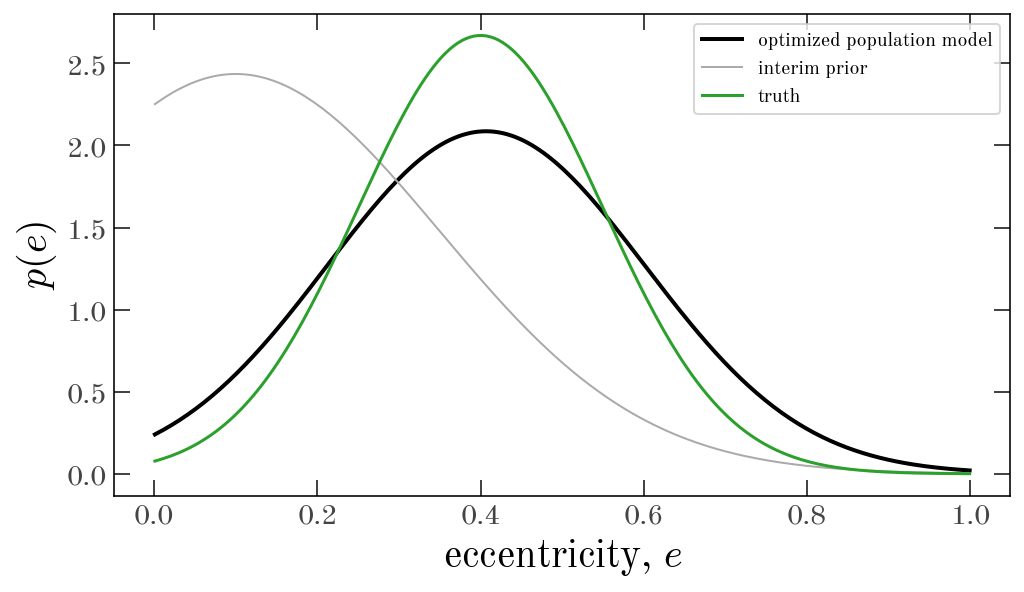

In [23]:
e_grid = np.linspace(1e-3, 1 - 1e-3, 200)
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.plot(
    e_grid,
    truncnorm_pdf(e_grid, mean_hat, std_hat),
    lw=2,
    marker="",
    label="optimized population model",
)
ax.plot(
    e_grid,
    jnp.exp(prior.nonlinear_priors["eccentricity"].log_prob(e_grid)),
    color="#aaaaaa",
    marker="",
    lw=1,
    label="interim prior",
)

ax.plot(
    e_grid,
    truncnorm_pdf(e_grid, *truths["ecc_dist_true"]),
    "tab:green",
    marker="",
    label="truth",
)

ax.set_xlabel("eccentricity, $e$")
ax.set_ylabel("$p(e)$")
ax.legend()

The inferred eccentricity distribution is similar to the truth (mean in the right place), but we don't expect a perfect match because we just did a single optimization rather than, e.g., running MCMC to get uncertainties on the inferred eccentricity distribution. Instead of doing that here, we will construct a more complex model to simultaneously infer the eccentricity distribution and a close binary fraction, as described below.

## Close binary fraction

First off, there is no such thing as a "close binary fraction" in the traditional sense. 
This term is usually used in an imprecise way to describe the fraction of stars that have a close binary companion. 
However, this often includes an imprecise (or ill-defined) threshold on the companion's mass and/or orbital properties (e.g., period). 
We will be precise here and define the close binary fraction to mean the fraction of stars with a companion in a defined region of period and companion mass space, $(P, M_2)$.
We use $P \in (1, 1000)\,\mathrm{day}$ and $M_2 > 0.1\,M_\odot$.
We next demonstrate two ways we can use the per-source posterior samples to estimate this close binary fraction in our sample. 

We first implement a simple estimator for the close binary fraction that uses the samples directly.
Conceptually, this is like counting the number of stars with companions in the specified $(P, M_2)$ region, but accounts for the fact that we often have significant uncertainty in the inferred orbital parameters.
This path is quick and straightforward, but it doesn't fully utilize the information in the posterior samples.

We then implement a more sophisticated (and significantly more complicated) hierarchical inference approach that models the population of companions in period, companion mass, and eccentricity, $(P, M_2, e)$, using continuous distributions. 
We use the per-source posterior samples to construct the hierarchical model and infer the parameters of the distributions, including the close binary fraction.

Both methods rely on computing posterior samples for the companion mass, $M_2$, for each star in the sample -- this is just a transformation of the orbital parameters, but it requires an estimate of the primary mass $M_1$ and an assumption about the inclination $i$ of the orbit.

#### Companion mass, $M_2$

We estimate the corresponding companion mass $M_2$ for each posterior sample by assuming we have an independent estimate of the primary mass $M_1$ for each star, and assuming that the inclination $i$ is isotropic (but unobserved).
That is, for each posterior sample over orbital parameters $\theta_{nk} = (P, e, K)_{nk}$, we sample an $(M_1, \sin i)$ pair from the error distribution of $M_1$ and an isotropic prior for $\cos i$. We then solve for $M_{2, nj}$ using the standard mass function relation for single-lined spectroscopic binaries:
$$
\frac{(M_2 \, \sin i)^3}{(M_1 + M_2)^2} = \frac{P \, K^3}{2\pi \, G} (1 - e^2)^{3/2}
\quad .
$$ 

We draw $M_1$ samples from a Gaussian with mean and standard deviation taken from the catalog, and draw $\cos i$ from a uniform distribution on $[-1, 1]$.
{func}`harv.kepler.masses.companion_mass_from_mass_function` solves for the companion mass:

In [24]:
# placeholder catalogue uncertainty on M_1 -- this should be taken from the catalog, but
# we just use a constant value here for demonstration
m1_err = Q(0.05, "Msun")

# mock "observe" the M_1 values by adding noise to the truth values
key = jr.key(42)
key, key_m1 = jr.split(key)

m1_pad_k = Q(
    truths["M1"][:, None]
    + ustrip("Msun", m1_err) * jr.normal(key_m1, (N_stars, K_max)),
    "Msun",
)

In [25]:
key, key_cos = jr.split(key)
cos_i_pad = jr.uniform(key_cos, (N_stars, K_max), minval=-1.0, maxval=1.0)
sini_pad_k = jnp.sqrt(1.0 - cos_i_pad**2)

Note: if you need to compute $M_2$ for a large number of stars, you can use {func}`harv.kepler.binary_mass_function` and {func}`harv.kepler.companion_mass_from_mass_function` in a vectorized way to compute $M_2$ for all of the posterior samples across all of the stars in one go. However, you have to first pre-construct 2D arrays of the period, semi-amplitude, and eccentricity samples for all of the stars with padded arrays for stars with fewer posterior samples than the maximum across the sample. Here we just use a for loop for simplicity and because we only have 100 stars in our sample:

In [ ]:
posteriors_with_m2 = []
for n, _s in enumerate(posteriors):
    # Enforce K > 0 first.  The rejection-sampler posterior on (K, arg_peri)
    # is bimodal -- (K, w) and (-K, w + pi) predict the same orbit.
    s = _s.wrap_angles()
    s_new = copy.deepcopy(s)

    m1_n = m1_pad_k[n, : s.n_samples]
    sini_n = sini_pad_k[n, : s.n_samples]

    mf = masses.binary_mass_function(s["period"], s["rv_semiamp"], s["eccentricity"])
    m2 = masses.companion_mass_from_mass_function(mf, m1=m1_n, sini=sini_n)
    s_new.nonlinear["m2"] = m2

    # Precompute ln|dM2/dK| at fixed (P, e, M1, sini)
    M2_v = ustrip("Msun", m2)
    K_v = ustrip("km/s", s["rv_semiamp"])
    M1_v = ustrip("Msun", m1_n)
    log_dM2_dK = jnp.log(M2_v / K_v) - jnp.log(
        jnp.abs(1.0 - (2.0 / 3.0) * M2_v / (M1_v + M2_v))
    )
    s_new.nonlinear["log_dM2_dK"] = Q(log_dM2_dK, "")

    posteriors_with_m2.append(s_new)

### The estimator approach

If all stars were edge-on ($\sin i = 1$) and we had perfect knowledge of $M_1$ and all of the orbital parameters, we could compute the binary fraction simply by counting the fraction of stars with $P$ and $M_2$ in the defined region of parameter space. 
In practice, we have to account for the uncertainty in all of these quantities, and often our constraints on $P$ and $M_2$ are quite broad or multi-modal.
A simple estimator for the close binary fraction is to compute the probability that each star has $P$ and $M_2$ in the defined region of parameter space by counting the fraction of posterior samples that satisfy the condition. 
That is, we define an indicator function $I_{nk}$ for each posterior sample $k$ of star $n$ that is 1 if the sample satisfies the condition and 0 otherwise:
$$
I_{nk} = \begin{cases} 1 & P_{\mathrm{min}} < P_{nk} < P_{\mathrm{max}} \text{ and } M_{2,nk} > M_{2,\mathrm{cut}} \\ 0 & \text{otherwise} \end{cases}
$$
where we defined our adopted period limits $P_\mathrm{min}$ and $P_\mathrm{max}$ and the companion mass cut $M_{2,\mathrm{cut}}$ above.

From this, we can compute the probability that star $n$ has a companion in the defined region of parameter space as the fraction of posterior samples that satisfy the condition:
$$
p_n = \frac{1}{K_n} \sum_{k=1}^{K_n} I_{nk}.
$$

Let's compute these things for each star in our sample:

In [27]:
# Binary fraction cuts defined above
P_MIN_CUT = Q(1.0, "day")
P_MAX_CUT = Q(1000.0, "day")
M2_MIN_CUT = Q(0.1, "Msun")
M2_MAX_CUT = Q(1.0, "Msun")

In [28]:
p_n = jnp.array(
    [
        jnp.sum(
            (s["period"] > P_MIN_CUT)
            & (s["period"] < P_MAX_CUT)
            & (s["m2"] > M2_MIN_CUT)
        )
        / s.n_samples
        for s in posteriors_with_m2
    ]
)

Note that this approach does not factor in any uncertainty on the probabilities.

/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_41684/3257386766.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


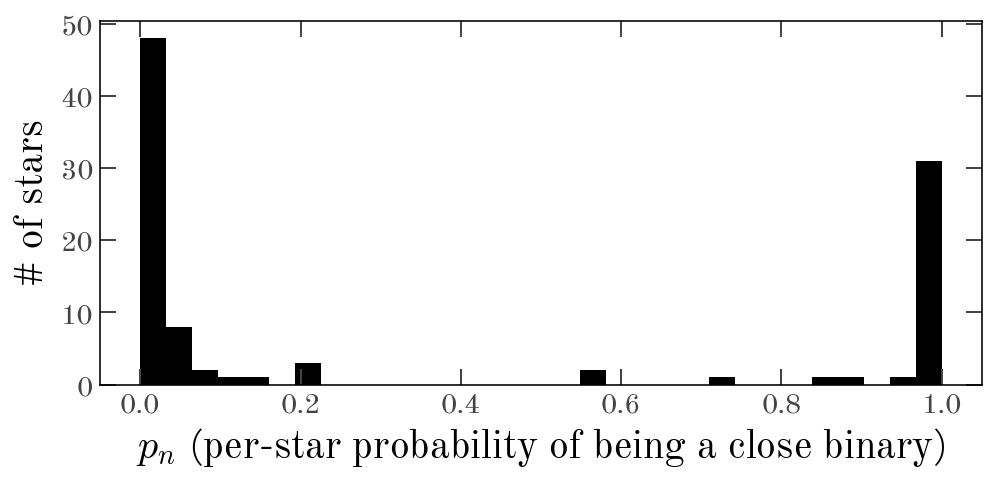

In [29]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(p_n, bins=np.linspace(0, 1, 32))
ax.set_xlabel("$p_n$ (per-star probability of being a close binary)")
ax.set_ylabel("# of stars")
fig.tight_layout()

With the per-star probabilities $p_n$ in hand, we can compute the close binary fraction by optimizing the likelihood:
$$
\mathcal{L}(f) = \prod_{n=1}^N \left[(1 - f)(1 - p_n) + f\, p_n\right].
$$

In [30]:
def neg_log_likelihood_f(f: float, p: np.ndarray) -> float:
    val = (1.0 - f) * (1.0 - p) + f * p
    # Guard against log(0) on the boundary.
    return -np.log(np.clip(val, 1e-300, None)).sum()


res_f = opt.minimize_scalar(
    neg_log_likelihood_f, args=(p_n,), bounds=(0.0, 1.0), method="bounded"
)
f_hat = float(res_f.x)
print(f"Best-fit close binary fraction: f_hat = {f_hat:.3f}")
print(f"  truth: f = {truths['binary_fraction_true']:.3f}")

Best-fit close binary fraction: f_hat = 0.362
  truth: f = 0.400


OK - we got somewhat close to the true value, but we also want to know the uncertainty on our estimate of $f$. We estimate this uncertainty with _bootstrap_ resamplings of the data (here: the per-star probabilities):

bootstrap percentiles (16/50/84): 0.31 / 0.36 / 0.42
f_hat = 0.36 (-0.05, +0.05)


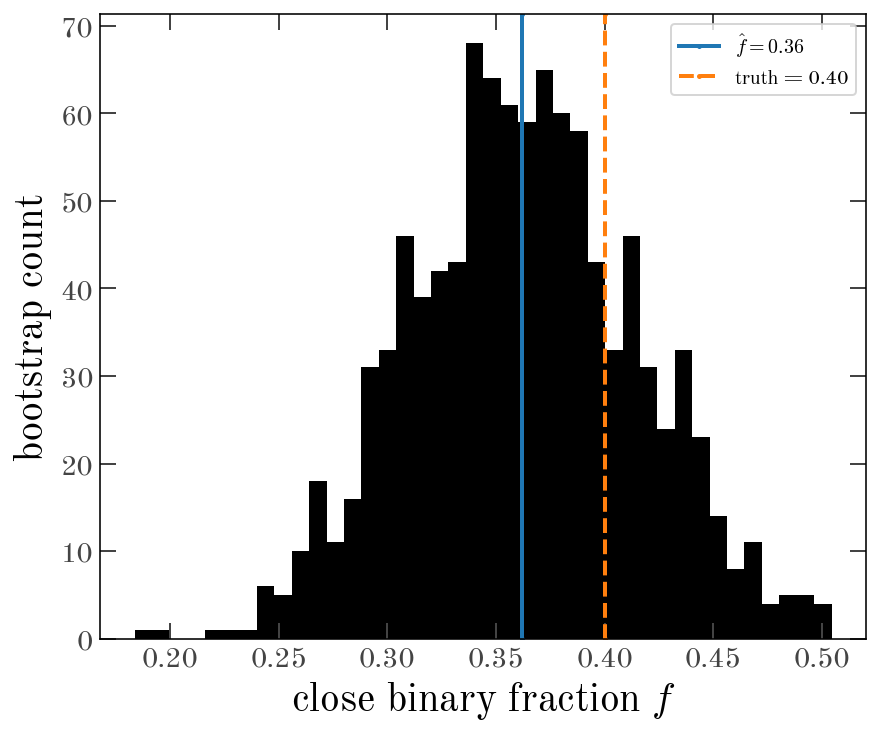

In [31]:
N_BOOT = 1024
rng = np.random.default_rng(0)
f_boot = np.empty(N_BOOT)

for b in range(N_BOOT):
    idx = rng.integers(0, p_n.size, size=p_n.size)
    r = opt.minimize_scalar(
        neg_log_likelihood_f,
        args=(p_n[idx],),
        bounds=(0.0, 1.0),
        method="bounded",
    )
    f_boot[b] = r.x

lo, med, hi = np.percentile(f_boot, [16, 50, 84])
print(f"bootstrap percentiles (16/50/84): {lo:.2f} / {med:.2f} / {hi:.2f}")
print(f"f_hat = {f_hat:.2f} (-{f_hat - lo:.2f}, +{hi - f_hat:.2f})")

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.hist(f_boot, bins=40)
ax.axvline(f_hat, color="C1", lw=2, label=f"$\\hat f = {f_hat:.2f}$")
if "binary_fraction_true" in truths:
    ax.axvline(
        truths["binary_fraction_true"],
        color="C2",
        lw=2,
        ls="--",
        label=f"truth = {truths['binary_fraction_true']:.2f}",
    )
ax.set_xlabel("close binary fraction $f$")
ax.set_ylabel("bootstrap count")
ax.legend()

It looks like our estimate of the close binary fraction is consistent with the true value (within the bootstrap uncertainty on the binary fraction), but perhaps biased a little to lower values. We can do better by implementing a hierarchical model for the population of companions in $(P, M_2)$ space and inferring the parameters of that model. We develop this model in the next sections, but it requires quite a bit more infrastructure.

## Joint hierarchical inference of $f$ and $p(M_2, P, e)$

The simple estimator in the previous section computes the close binary fraction by thresholding the per-sample posterior and counting how many samples pass our cuts. 
That works, but is sensitive to two main issues:

1. Boundary bias: Binaries with true $M_2$ near the cut have posterior $M_2$ spread on both sides of the boundary. The hard-cut estimator counts only the in-box samples, so the contribution is biased low as you approach the boundary from above (this biases $\hat f$ to lower values).
2. Binary vs. single identifiability: A true single star (no companion, so $K = 0$) and a true binary with very small $K$ both produce posterior $M_2$ samples close to zero. Any model that only looks at the inferred $M_2$ distribution cannot disentangle the two without an explicit "no companion" component of the model.

The principled way to handle these issues is to instead jointly infer the population distributions of $M_2$, $P$, and $e$ together with the binary fraction $f$.
We parameterize the binary population as:
- $M_2 \sim \mathrm{LogNormal}(\mu_{\log M_2},\, \sigma_{\log M_2})$ left-truncated at a minimum mass defined by our cut above $M_{2,\min} = 0.1\,M_\odot$. This truncation is important, because the model could instead find a degenerate model in which $p(M_2)$ widens to include significant support at $M_2 \approx 0$ and singles masquerade as very-low-mass binaries, pushing $f \to 1$.
- $e \sim \mathrm{TruncatedNormal}(\mu_e,\, \sigma_e)$ on $[0, 1]$,
- $P \sim \mathrm{TruncatedNormal}(\mu_P,\, \sigma_P)$ on $[P_{\rm min}, P_{\rm max}]$,

We then construct a hierarchical mixture model between the above binary star population model, and a single star model (constant velocity $K=0$).
The mixture model is defined as:
$$
p(D_n \mid f, \boldsymbol\alpha) \;=\; f\,p_\mathrm{binary}(D_n \mid \boldsymbol\alpha) \;+\; (1 - f)\,p_\mathrm{single}(D_n),
$$
where $f$ is the close binary fraction in the population, and $\boldsymbol{\alpha}$ represents the binary population model hyperparameters:
$$
\boldsymbol\alpha = (\mu_{\log M_2}, \sigma_{\log M_2}, \mu_e, \sigma_e, \mu_{\log P}, \sigma_{\log P}) \quad .
$$
In the mixture model above, $p_\mathrm{binary}(D_n \mid \boldsymbol\alpha)$ and $p_\mathrm{single}(D_n)$ represent the marginal likelihoods of some radial velocity data $D_n$ given the binary and a single star models, respectively. 
The marginalization is performed over the Keplerian orbital parameters for the binary model (i.e., $P$, $e$, and $M_2$), and over the parameters of the single star model (which we define below, but is a flat $K=0$ model with a constant velocity).

The binary population's support is the close-binary cut box: $\log M_2$ is truncated at a minimum mass, and the period hyperprior is bounded by our adopted period range.
In a real application, we might want a third component of the model to absorb any systems that are not well defined by binary models in this range of parameters nor the single star model, but here for simplicity we only include the two components.
With this setup, the mixture weight $f$ directly represents the fraction of stars in the population that are close binaries, as defined by our truncation criteria.

The single-component marginal likelihood $p_\mathrm{single}(D_n)$ is computed analytically below, and the the binary marginal likelihood $p_\mathrm{binary}(D_n \mid \boldsymbol\alpha)$ is approximated with the "importance sampling trick" used above.

### The single-star marginal likelihood

If a star is truly single, its radial-velocity measurements should be consistent with a constant velocity plus the observational noise. We model this by assuming the systemic velocity $v_\mathrm{sys}$ is the same at every epoch and the residuals are Gaussian with the reported uncertainties:
$$
rv_{t,n} \mid v_\mathrm{sys},\, \sigma_{t,n} \sim \mathcal{N}\!\left(v_\mathrm{sys},\, \sigma_{t,n}^2\right) \quad .
$$
We adopt the same prior on $v_\mathrm{sys}$ as the rejection sampler for the binary model: a zero-mean Normal with width $\sigma_{v_0}$. Both the likelihood and the prior are Gaussian, so we can marginalize $v_\mathrm{sys}$ analytically:
$$
p_\mathrm{single}(D_n) = \int p(D_n \mid v_\mathrm{sys})\, p(v_\mathrm{sys})\, dv_\mathrm{sys} \quad .
$$

Defining the inverse variance sums:
$$
A_n = \frac{1}{\sigma_{v_0}^2} + \sum_t \frac{1}{\sigma_{t,n}^2}, \qquad
B_n = \sum_t \frac{rv_{t,n}}{\sigma_{t,n}^2}\quad ,
$$

the marginalization integral has a closed-form solution:

$$
\ln p_\mathrm{single}(D_n) = \tfrac{1}{2}\ln\!\frac{2\pi}{A_n} + \tfrac{1}{2}\frac{B_n^2}{A_n} - \tfrac{1}{2}\sum_t \frac{rv_{t,n}^2}{\sigma_{t,n}^2} - \tfrac{1}{2}\ln(2\pi\sigma_{v_0}^2) - \tfrac{1}{2}\sum_t \ln(2\pi\sigma_{t,n}^2)\quad .
$$

This gives us a single number for each star, which we can compute from the data and the prior variance alone. For a star whose RV measurements are well-fit by a constant velocity, $\ln p_\mathrm{single}$ should be relatively high.

Note that the above marginalization math assumes that the observational uncertainties $\sigma_{t,n}$ are known exactly. If your model includes an unknown "jitter" parameter, the marginalization is no longer analytic, and we would have to handle the jitter parameter numerically (but this would still be straightforward).

We compute $\ln p_\mathrm{single}(D_n)$ for every star in our sample:


In [32]:
unit = d.rv.unit

sigma_v0_Q = Q(
    prior.linear_priors["v_sys"].distribution.scale, prior.linear_priors["v_sys"].unit
)
sigma_v0 = ustrip(unit, sigma_v0_Q)

log_p_sing = jnp.empty(N_stars)
for n, d in enumerate(datasets):
    rv = ustrip(unit, d.rv)
    err = ustrip(unit, d.rv_err)

    A = 1.0 / sigma_v0**2 + jnp.sum(1.0 / err**2)
    B = jnp.sum(rv / err**2)
    log_p_sing = log_p_sing.at[n].set(
        0.5 * jnp.log(2.0 * jnp.pi / A)
        + 0.5 * B**2 / A
        - 0.5 * jnp.sum(rv**2 / err**2)
        - 0.5 * jnp.log(2.0 * jnp.pi * sigma_v0**2)
        - 0.5 * jnp.sum(jnp.log(2.0 * jnp.pi * err**2))
    )

### The binary marginal likelihood via importance sampling

The binary marginal likelihood is more complex than the single-star case because we now have to integrate the data likelihood against the population density over the multi-dimensional orbital parameter space $(P, e, K)$, with two additional nuisance parameters $(M_1, \sin i)$ entering through the conversion to $M_2$. 
There is no closed form expression here, but we do have posterior samples in $(P, e, K)$ for every star from running the rejection sampler above. 
The same importance-sampling trick we used for the eccentricity inference above therefore gives us an estimator with those samples:

$$
\begin{align*}
p_\mathrm{binary}(D_n \mid \boldsymbol\alpha)
    \;&=\; \int \mathrm{d}\boldsymbol{\theta}_n \,
    p(D_n \mid \boldsymbol{\theta}_n) \, 
    p(\boldsymbol{\theta}_n \mid \boldsymbol\alpha)
    \\
\;&\approx\;
    Z_n^\mathrm{int} \, 
    \frac{1}{K_n} \sum_{k=1}^{K_n} \,
    \frac{p_\mathrm{pop}^\mathrm{binary}(\theta_{nk} \mid \boldsymbol\alpha)}{p_\mathrm{int}(\theta_{nk})} 
    \\
\;&=\;
    Z_n^\mathrm{int} \, 
    \frac{1}{K_n} \sum_{k=1}^{K_n} \,
    w_{nk}(\boldsymbol\alpha)
    \\
\;&=\;
    Z_n^\mathrm{int} \, w_n(\boldsymbol\alpha) 
\end{align*}
\quad ,
$$

where $\theta_{nk}$ is the $k$-th posterior sample of the orbital parameters for star $n$, $p_\mathrm{int}$ is the interim prior used by the rejection sampler, and $Z_n^\mathrm{int}$ is the full marginal likelihood (FML, or evidence) of the binary model under that interim prior. 
We'll come back to $Z_n^\mathrm{int}$ in a moment - we'll first define the per-sample weight $w_{nk}(\boldsymbol\alpha)$ from the importance-sampling ratio.

One new complication relative to the the importance-sampling integral in the eccentricity distribution inference above is that this population model is defined over $(P, e, M_2)$ while the posterior samples live in $(P, e, K)$. 
We connect the two by treating $(M_1, \sin i)$ as auxiliary parameters drawn from a catalog distribution and an isotropic inclination prior, the same way we did when we computed posterior samples of $M_2$ in a previous section. 
At fixed $(P, e, M_1, \sin i)$, the change of variables $K \leftrightarrow M_2$ is one-to-one, and the binary population density transforms as
$$
p_\mathrm{pop}^\mathrm{binary}(P, e, K)
\;=\;
p_\mathrm{pop}^\mathrm{binary}(P, e, M_2(K)) \cdot \left|\frac{\partial M_2}{\partial K}\right| \quad .
$$

We can compute the Jacobian from differentiating the standard RV semi-amplitude relation and inverting it
$$
K \;=\; (2\pi G/P)^{1/3}\,\frac{M_2\, \sin i}{(M_1 + M_2)^{2/3}\sqrt{1 - e^2}} \quad .
$$

Putting it together, the per-sample importance weight is a product of three population/interim ratios (and the Jacobian), because the prior is separable:
$$
\begin{align*}
w_{nk}(\boldsymbol\alpha) \;&=\;
    \frac{p_\mathrm{pop}^{P}(P_{nk} \mid \mu_{\log P}, \sigma_{\log P})}{p_\mathrm{int}^{P}(P_{nk})} \\
    &\times \frac{p_\mathrm{pop}^{e}(e_{nk} \mid \mu_e, \sigma_e)}{p_\mathrm{int}^{e}(e_{nk})} \\
    &\times \frac{p_\mathrm{pop}^{M_2}(M_2^{(nk)} \mid \mu_{\log M_2}, \sigma_{\log M_2})}{p_\mathrm{int}^{K}(K_{nk} \mid P_{nk}, e_{nk})} \\
    &\times \left|\frac{\partial M_2}{\partial K}\right|_{nk} 
\end{align*}
\quad .
$$
Note that the $M_2$ population ratio has an interim prior on the semi-amplitude $K$ (rather than an $M_2$-space density): this is where the change of variables enters, and thus the need for the Jacobian factor at the end of the expression.

One quick note on the period term: The densities above are defined in terms of $P$, but the interim prior and population density are both defined in terms of $\log P$, so it's slightly easier to work with $\log P$ instead (as we do in code below).

We still need the FML or evidence, $Z_n^\mathrm{int}$, which is the fully marginalized likelihood of the binary model under the interim prior. 
This is the binary analog of $p_\mathrm{single}$: a per-star constant that doesn't depend on the population hyperparameters. 
We need this factor here (and not in the eccentricity distribution example above) because the mixture model compares $p_\mathrm{binary}$ to $p_\mathrm{single}$, and we need the relative normalization to make the comparison meaningful. 

Unlike $p_\mathrm{single}$, there is no closed form for $Z_n^\mathrm{int}$, and it is often risky to compute it directly.
For sources with broad, multi-modal structure in the log-likelihood (i.e. cases where the rejection sampler works and returns many samples), we use the already-computed log-likelihood values over all prior samples to estimate the evidence (in fact, this is why we ran the rejection sampler with `return_evidence_stats=True` far above).
Under the hood, this uses a Monte Carlo integration approach to estimate the evidence.
In a real research project, this would need to be validated carefully to ensure the accuracy of the evidence estimates.

In [33]:
log_Z_int = jnp.array([s.metadata["logZ_int"] for s in posteriors])

As a sanity check, here is a very crude estimate of the binary fraction using the evidence ratio of the binary vs. single-star models:

In [34]:
np.sum((log_Z_int - log_p_sing) > 0) / len(log_Z_int)

Array(0.38, dtype=float64)

#### Importance-sampling log densities for binaries

Our definition of "close binary" includes hard cuts on the companion mass and orbital period. We also have some systems with fewer than 1024 posterior samples because they did not pass the "unimodal" check in order to be included in the MCMC follow-up sampling. For these systems, we need to pad and mask out the samples that are not valid.

First, we take the list of samples objects (from either rejection sampling or from the MCMC follow-up) and pad and stack them into a single batched `Samples` object:

In [35]:
stacked_samples, pad_mask = pad_and_stack_samples(posteriors_with_m2)
print(f"Number of stars: {stacked_samples.batch_shape[0]}")
print(f"Number of samples per star: {stacked_samples.n_samples}")

Number of stars: 100
Number of samples per star: 1024


Now the corresponding parameter values have shape (100, 1024) - the sources with fewer than the maximum number of samples will have their extra values padded with "nan" values:

In [36]:
stacked_samples["period"].shape

(100, 1024)

In [37]:
jnp.isnan(stacked_samples["period"]).sum(axis=1)

Array([   0,    0,    0,    0,    0,    0,  999,    0,    0,    0,    0,
          0,  992,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       1005,  337,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0, 1020, 1011,  655,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,  946,    0,    0,    0,    0,
        891,    0,    0,    0,    0,    0,    0,    0,    0,    0,  987,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,  584,    0,    0,    0,    0,  735,
          0,    0,    0,    0,    0,  995, 1022,    0,    0,    0,    0,
          0], dtype=int64)

Next, we need to additionally mask out samples that are outside the domain of the population model for binaries. Recall that we defined a range of periods and companion masses that we will call "close binaries" - we will work with truncated distributions to represent period and M2, so we need to make sure our mask accounts for the domains of these truncated distributions.

In [39]:
P_raw = ustrip("day", stacked_samples["period"])
e_raw = ustrip("", stacked_samples["eccentricity"])
K_raw = ustrip("km/s", stacked_samples["rv_semiamp"])
M2_raw = ustrip("Msun", stacked_samples["m2"])

# build a mask for: real (non-padded) sample AND inside every population truncation
in_P = (P_raw > ustrip("day", P_MIN_CUT)) & (P_raw < ustrip("day", P_MAX_CUT))
in_M2 = (M2_raw > ustrip("Msun", M2_MIN_CUT)) & (M2_raw < ustrip("Msun", M2_MAX_CUT))
keep_mask = pad_mask & in_P & in_M2

n_pad = int((~pad_mask).sum())
n_dropped = int((pad_mask & ~keep_mask).sum())
print(
    f"Kept samples: {int(keep_mask.sum())}  "
    f"(padded: {n_pad}; dropped as out-of-support: {n_dropped})"
)

Kept samples: 21237  (padded: 12179; dropped as out-of-support: 68984)


In [ ]:
e_safe = jnp.where(keep_mask, e_raw, 0.5)
K_safe = jnp.where(keep_mask, K_raw, 1.0)
P_safe = jnp.where(keep_mask, P_raw, 100.0)
M2_safe = jnp.where(keep_mask, M2_raw, 0.5)
log10_P_safe = jnp.log10(P_safe)
log10_M2_safe = jnp.log10(M2_safe)

for vals in [e_safe, K_safe, P_safe, M2_safe, log10_P_safe, log10_M2_safe]:
    if jnp.isfinite(vals).any():
        print(f"ERROR: Non-finite values found in {vals}")

For the importance sampling sum, we need the count of all valid (non-padded) samples for the denominator. This is an important point: This is _not_ the count of samples that survived the population-truncation filter. Samples that are dropped because they are out of domain for the population model are still draws from the interim prior -- they contribute zero weight but must still appear in the $K_n$ denominator.

In [41]:
ln_K_n = jnp.log(jnp.maximum(pad_mask.sum(axis=1), 1.0))

Now we can use these values to compute the denominators of the importance sampling ratios defined above. These are the (log) values of $p^{\rm int}(P)$, $p^{\rm int}(e)$, and $p^{\rm int}(K \mid P, e)$.

The period term looks weird, but this comes from the normalization of a prior that is uniform in $\log_{10} P$:
$$
p^{\rm int}(\log_{10} P) = \frac{1}{\log_{10} P_{\rm max} - \log_{10} P_{\rm min}}
$$
$$
\log p^{\rm int}(\log_{10} P) = -\log(\log_{10} P_{\rm max} - \log_{10} P_{\rm min})
$$

In [42]:
log_pint_logP = -float(
    jnp.log(jnp.log10(ustrip("day", P_MAX_CUT)) - jnp.log10(ustrip("day", P_MIN_CUT)))
)
log_pint_e_pad = prior.nonlinear_priors["eccentricity"].log_prob(e_safe)

# Interim p(K|P,e) is a function of period and eccentricity:
_k_params = SimpleNamespace(period=Q(P_safe, "day"), eccentricity=Q(e_safe, ""))
log_pint_K_pad = prior.linear_priors["rv_semiamp"](_k_params).distribution.log_prob(
    K_safe
)

# Jacobian was precomputed per sample in the M2-augmentation cell above.
log_dM2_dK_pad = jnp.where(keep_mask, ustrip("", stacked_samples["log_dM2_dK"]), 0.0)

A few more definitions that we'll need in the population model:

In [43]:
LOG_M2_LOW = jnp.log10(ustrip("Msun", M2_MIN_CUT))
LOG_M2_HIGH = jnp.log10(ustrip("Msun", M2_MAX_CUT))
LOG_P_CUT_LOW = jnp.log10(ustrip("day", P_MIN_CUT))
LOG_P_CUT_HIGH = jnp.log10(ustrip("day", P_MAX_CUT))

Now we can construct the hierarchical model using numpyro:

In [44]:
def population_model():
    # The binary fraction, f
    f = numpyro.sample("f", dist.Uniform(0.0, 1.0))

    # Hyperparameter priors - these are the population parameters we want to infer
    mean_logM2 = numpyro.sample(
        "mean_logM2", dist.Uniform(jnp.log10(0.1), jnp.log10(2.0))
    )
    std_logM2 = numpyro.sample("std_logM2", dist.Uniform(0.05, 1.5))
    mean_e = numpyro.sample("mean_e", dist.Uniform(0.05, 0.95))
    std_e = numpyro.sample("std_e", dist.Uniform(0.05, 0.5))
    mean_logP = numpyro.sample("mean_logP", dist.Uniform(-2.0, 8.0))
    std_logP = numpyro.sample("std_logP", dist.Uniform(0.1, 5.0))

    # Binary-component terms:
    trunc_logM2 = dist.TruncatedNormal(
        mean_logM2,
        std_logM2,
        low=LOG_M2_LOW,
        high=LOG_M2_HIGH,
    )
    # the -log10(M2) accounts for the change of variables from M2 to log10(M2)
    log_pop_M2 = trunc_logM2.log_prob(log10_M2_safe) - log10_M2_safe

    log_pop_e = dist.TruncatedNormal(
        mean_e,
        std_e,
        low=0.0,
        high=1.0,
    ).log_prob(e_safe)

    log_pop_logP = dist.TruncatedNormal(
        mean_logP,
        std_logP,
        low=LOG_P_CUT_LOW,
        high=LOG_P_CUT_HIGH,
    ).log_prob(log10_P_safe)

    # Per-sample binary importance-sampling integrand
    log_w_per_sample = (
        log_pop_M2
        + log_pop_e
        - log_pint_e_pad
        + log_pop_logP
        - log_pint_logP
        + log_dM2_dK_pad
        - log_pint_K_pad
    )
    log_w_per_sample = jnp.where(keep_mask, log_w_per_sample, -jnp.inf)

    # Inner sum over samples:
    log_bar_w = jax.scipy.special.logsumexp(log_w_per_sample, axis=1) - ln_K_n
    log_bar_w = jnp.where(jnp.isfinite(log_bar_w), log_bar_w, -jnp.inf)

    # Per-star mixture: binary side scaled by Z_int + single side
    log_lik_per_star = jnp.logaddexp(
        jnp.log(f) + log_Z_int + log_bar_w,
        jnp.log1p(-f) + log_p_sing,
    )
    numpyro.factor("loglik", log_lik_per_star.sum())

Now we can run MCMC with a NUTS sampler:

In [45]:
kernel = NUTS(population_model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=4, progress_bar=True)
mcmc.run(jr.key(8675309))
pop_samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
           f      0.40      0.05      0.40      0.32      0.48    979.73      1.01
      mean_e      0.35      0.05      0.35      0.27      0.43    934.21      1.00
  mean_logM2      0.03      0.15      0.03     -0.18      0.28    918.31      1.00
   mean_logP      4.45      1.80      4.21      1.96      7.20    385.47      1.01
       std_e      0.20      0.05      0.19      0.13      0.27    781.82      1.00
   std_logM2      0.31      0.10      0.30      0.14      0.44    474.26      1.01
    std_logP      1.98      0.89      1.93      0.60      3.15    282.00      1.01

Number of divergences: 31


#### Corner plot of population parameters

The blue marker/lines in the below indicate the true population parameter values for the simulated dataset.

/Users/aprice-whelan/projects/harv/.venv/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


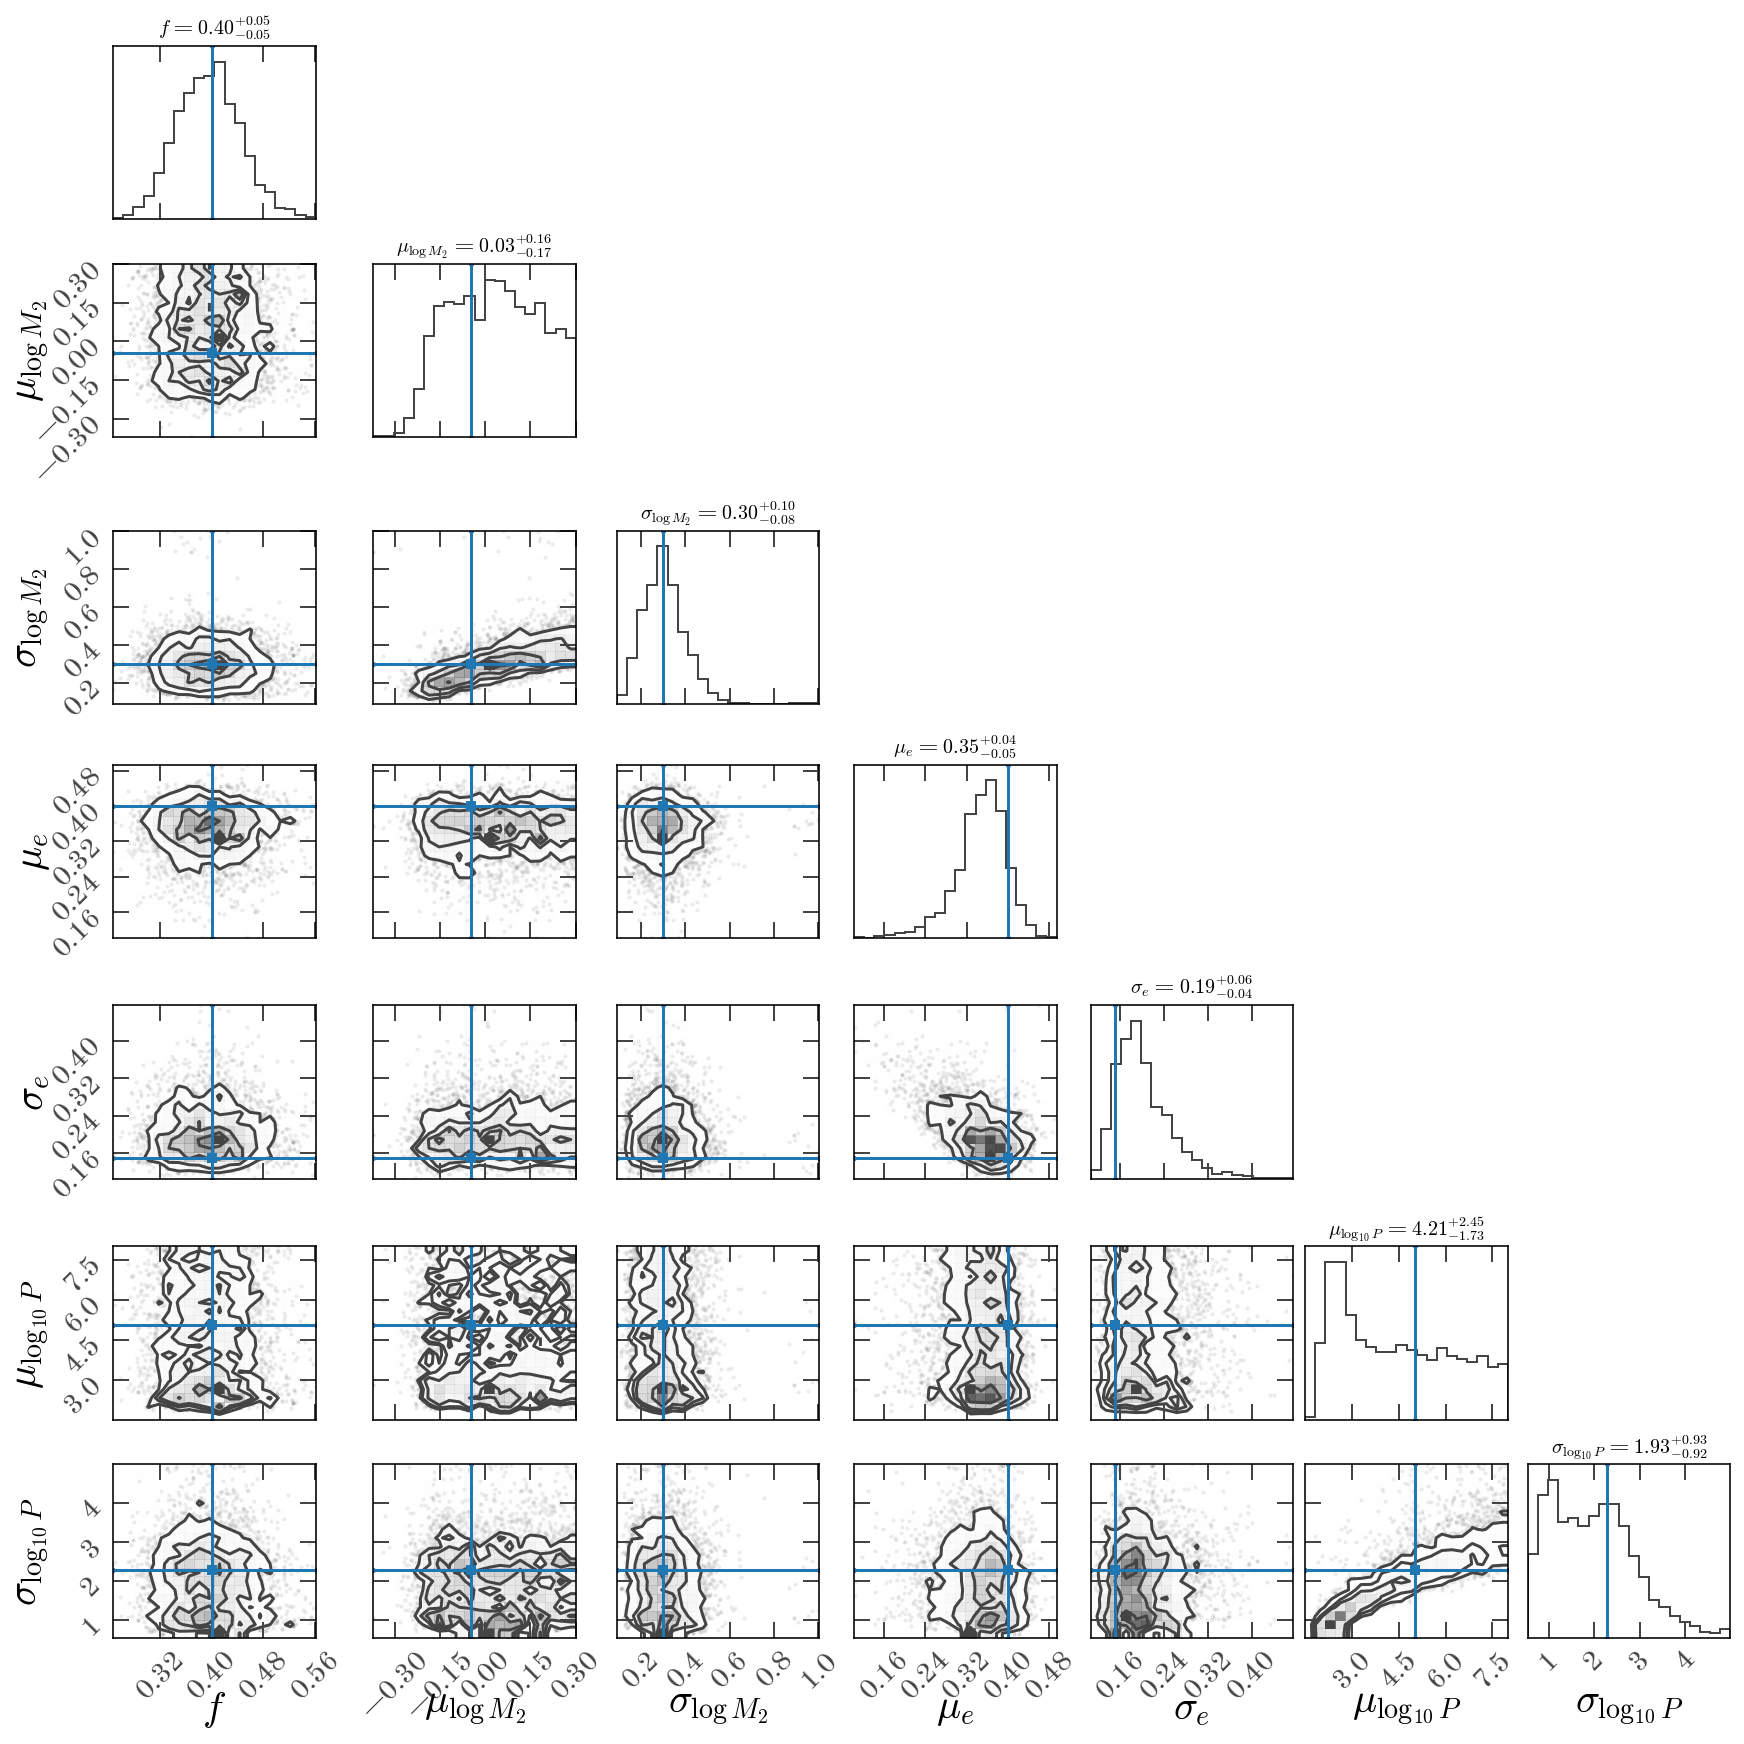

In [46]:
samples_arr = np.array(
    [
        pop_samples["f"],
        pop_samples["mean_logM2"],
        pop_samples["std_logM2"],
        pop_samples["mean_e"],
        pop_samples["std_e"],
        pop_samples["mean_logP"],
        pop_samples["std_logP"],
    ]
).T

truths_arr = np.array(
    [
        truths["binary_fraction_true"],
        truths["log10M2_mean_true"],
        truths["log10M2_std_true"],
        truths["ecc_dist_true"][0],
        truths["ecc_dist_true"][1],
        truths["log10P_mean_true"],
        truths["log10P_std_true"],
    ]
)
labels = [
    r"$f$",
    r"$\mu_{\log M_2}$",
    r"$\sigma_{\log M_2}$",
    r"$\mu_e$",
    r"$\sigma_e$",
    r"$\mu_{\log_{10} P}$",
    r"$\sigma_{\log_{10} P}$",
]

fig = plt.figure(figsize=(12, 12))
fig = corner.corner(
    samples_arr,
    labels=labels,
    truths=truths_arr,
    truth_color="C1",
    show_titles=True,
    fig=fig,
    title_kwargs={"fontsize": 10},
    hist_kwargs={"density": True},
)

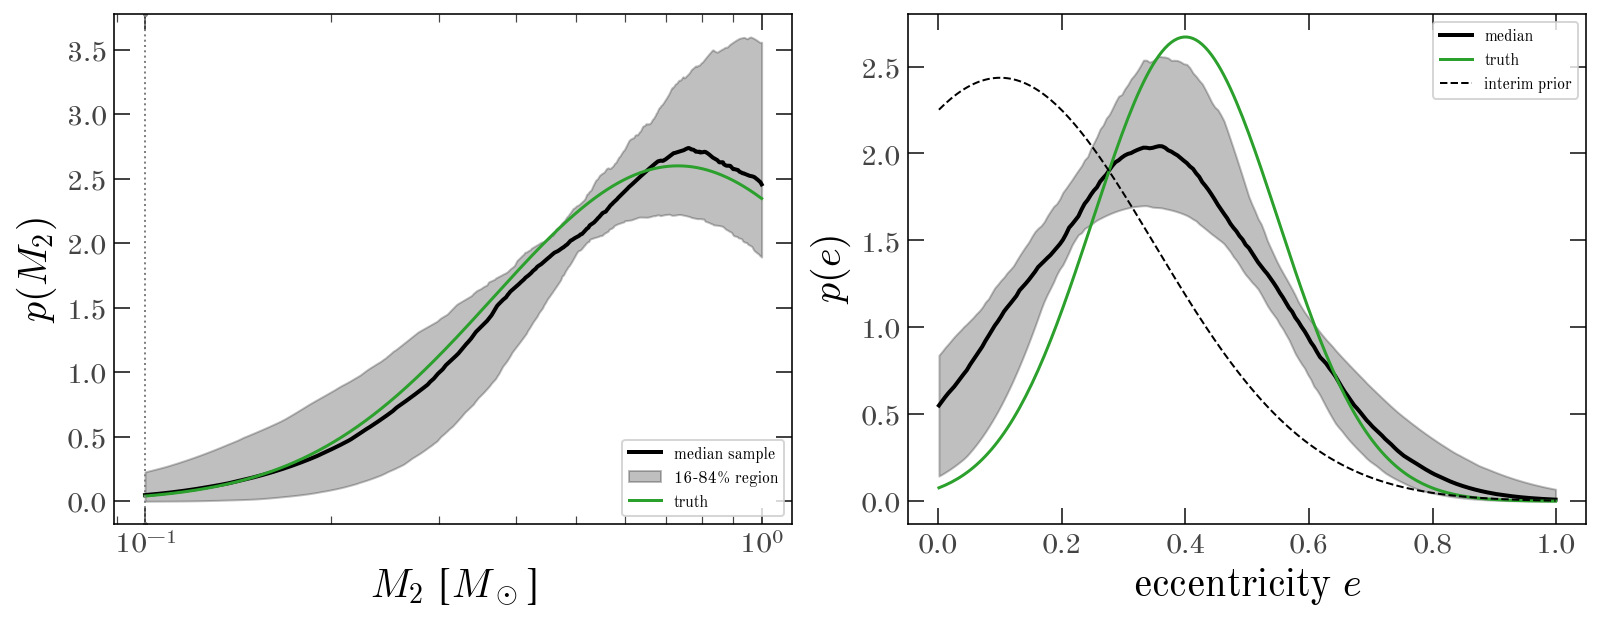

In [47]:
n_curves = 256

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")

# --------
# M2:
log_M2_grid = np.linspace(LOG_M2_LOW, LOG_M2_HIGH, 1024)

ln_curves_M2 = np.full((n_curves, log_M2_grid.size), -np.inf)
for i in range(n_curves):
    log_dens = dist.TruncatedNormal(
        pop_samples["mean_logM2"][i],
        pop_samples["std_logM2"][i],
        low=LOG_M2_LOW,
        high=LOG_M2_HIGH,
    ).log_prob(log_M2_grid)

    ln_curves_M2[i] = log_dens - log_M2_grid

pdf_curves = np.exp(ln_curves_M2)
lo, med, hi = np.percentile(pdf_curves, [16, 50, 84], axis=0)
axes[0].plot(10**log_M2_grid, med, "C0-", lw=2, label="median sample")
axes[0].fill_between(
    10**log_M2_grid, lo, hi, color="C0", alpha=0.25, label="16-84% region"
)

true_M2 = (
    dist.TruncatedNormal(
        truths["log10M2_mean_true"],
        truths["log10M2_std_true"],
        low=np.log10(truths["M2_min_Msun"]),
        high=np.log10(truths["M2_max_Msun"]),
    ).log_prob(log_M2_grid)
    - log_M2_grid
)
axes[0].plot(
    10**log_M2_grid,
    np.exp(true_M2),
    ls="-",
    marker="",
    color="tab:green",
    lw=1.5,
    label="truth",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("$M_2$ [$M_\\odot$]")
axes[0].set_ylabel("$p(M_2)$")
axes[0].legend(fontsize=8)
axes[0].axvline(0.1, color="grey", ls=":", lw=1)

# --------
# eccentricity:
e_grid = np.linspace(1e-3, 1 - 1e-3, 200)

ln_curves_e = np.empty((n_curves, e_grid.size))
for i in range(n_curves):
    ln_curves_e[i] = dist.TruncatedNormal(
        pop_samples["mean_e"][i], pop_samples["std_e"][i], low=0.0, high=1.0
    ).log_prob(e_grid)

lo, med, hi = np.percentile(ln_curves_e, [16, 50, 84], axis=0)
axes[1].plot(e_grid, np.exp(med), "C0-", lw=2, label="median")
axes[1].fill_between(e_grid, np.exp(lo), np.exp(hi), color="C0", alpha=0.25)
axes[1].plot(
    e_grid,
    np.exp(
        dist.TruncatedNormal(
            truths["ecc_mean_true"], truths["ecc_std_true"], low=0.0, high=1.0
        ).log_prob(e_grid)
    ),
    ls="-",
    marker="",
    color="tab:green",
    lw=1.5,
    label="truth",
)
axes[1].plot(
    e_grid,
    np.exp(prior.nonlinear_priors["eccentricity"].log_prob(e_grid)),
    "k--",
    lw=1,
    label="interim prior",
)
axes[1].set_xlabel("eccentricity $e$")
axes[1].set_ylabel("$p(e)$")
axes[1].legend(fontsize=8)

Finally, we can visualize the posterior samples over the close binary fraction, $f$:

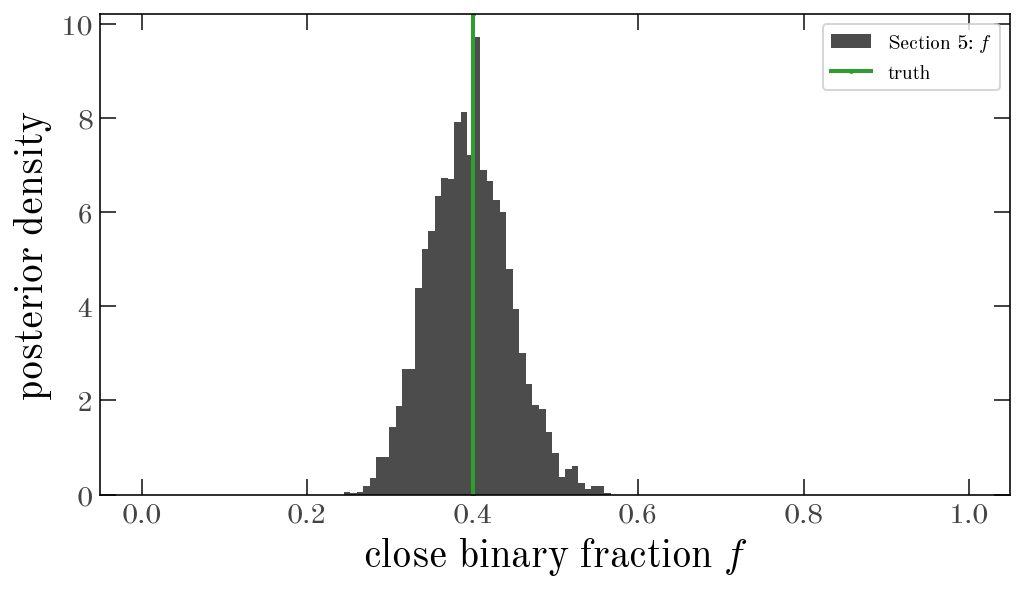

In [48]:
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.hist(
    pop_samples["f"],
    bins=np.linspace(0, 1, 128),
    density=True,
    alpha=0.7,
    color="C0",
    label="Section 5: $f$",
)
ax.axvline(truths["binary_fraction_true"], color="tab:green", lw=2, label="truth")
ax.set_xlabel("close binary fraction $f$")
ax.set_ylabel("posterior density")
ax.legend()

# Wrapping up

In this case study, we showed how to go from RV time series for a sample of stars to inference of a joint posterior pdf over the close binary fraction $f$ and the population distributions of $M_2$, $P$, and $e$.